In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from glob import glob

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({'font.size': 14})

In [19]:
# Shared inputs: population weights, regions, and the ACT/NAT/observed
# temperature time series.
#
# Unlike Figure3.ipynb (Brazil), there is no precomputed
# data/ext_temp_average_region.csv equivalent for Mexico, so the ACT/NAT
# temperature quantile bands are built here directly from the raw ensemble
# climate files (data/predict-all/ext-mex-ens*.csv / ext-mex-nat-ens*.csv) --
# the same files 03_fit_sensitivity_parallel_mexico_act.R / _nat.R read, and
# subject to the same caveat: those filenames are an assumed convention,
# unverified against the real files.
#
# Reading and aggregating 525 files x 2 (act + nat) is the expensive part of
# this notebook. It's done once here and reused for both models below, since
# the climate ensembles themselves don't depend on which of the two
# training-data models (Brazil+Mexico vs Mexico-only) is being shown --
# only the predicted dengue incidence does.

regions = ['Above 1000 m', 'Below 1000 m']

WINDOW_START = '2024-01-01'
WINDOW_END   = '2024-11-01'

pop = pd.read_csv(
    'data/model_input_mexico-peru-brazil_immunity.csv',
    usecols=['country', 'region', 'date_first_symptoms', 'population'],
    parse_dates=['date_first_symptoms'],
)
pop = pop[(pop['country'] == 'Mexico') & (pop['date_first_symptoms'] == WINDOW_START)]
pop = pop.groupby('region').agg({'population': 'sum'})
pop['population'] = pop['population'] / 1e6

obs = pd.read_csv(
    'data/model_input_mexico-peru-brazil_immunity.csv',
    usecols=['country', 'region', 'date_first_symptoms', 'mean_2m_air_temp_degree1'],
    parse_dates=['date_first_symptoms'],
)
obs = obs[obs['country'] == 'Mexico']
obs = obs.groupby(['region', 'date_first_symptoms']).mean(numeric_only=True).reset_index()


def load_ensemble_temp_quantiles(file_prefix):
    """Read every ensemble climate file matching file_prefix, aggregate
    monthly mean_2m_air_temp_degree1 by region x date, and return the
    2.5 / 50 / 97.5 percentiles across ensemble members."""
    files = sorted(glob(f'../dengue/predict-mexico-peru/{file_prefix}*.csv'))
    if len(files) == 0:
        raise FileNotFoundError(
            f"No files found matching ../dengue/predict-mexico-peru/{file_prefix}*.csv -- "
            "confirm the ensemble climate files are in place before running this cell."
        )

    frames = []
    for ensemble_idx, f in enumerate(files):
        df = pd.read_csv(
            f, usecols=['region', 'date_first_symptoms', 'mean_2m_air_temp_degree1'],
            parse_dates=['date_first_symptoms'],
        )
        df = df[df['region'].isin(regions)]
        monthly = df.groupby(['region', 'date_first_symptoms'])['mean_2m_air_temp_degree1'].mean().reset_index()
        monthly['ensemble_member'] = ensemble_idx
        frames.append(monthly)

    combined = pd.concat(frames, ignore_index=True)
    quantiles = combined.groupby(['region', 'date_first_symptoms'])['mean_2m_air_temp_degree1'] \
        .quantile([0.025, 0.5, 0.975]).reset_index()
    quantiles = quantiles.rename(columns={'level_2': 'quantile', 'mean_2m_air_temp_degree1': 'tas'})
    return quantiles


ext_temp = load_ensemble_temp_quantiles('ext-ens')
nat_temp = load_ensemble_temp_quantiles('ext-nat-ens')


In [21]:
def load_ensemble_incidence(path):
    df = pd.read_csv(path, parse_dates=['date_first_symptoms'])
    return df[df['region'].isin(regions)]


def compute_annual_incidence(df):
    """Sum predicted (and reconstructed actual) cases across all dates in
    the ensemble file per (region, ensemble_member), then convert back to an
    annual incidence. `actual_incidence` in our sensitivity script output is
    the same real observed value regardless of ensemble member, so summing
    it per member and averaging across members gives one reference value per
    region."""
    df = df.copy()
    df['actual_cases'] = df['actual_incidence'] * df['total_population'] / 1e5

    g = df.groupby(['region', 'ensemble_member']).agg(
        total_pred_cases=('total_pred_cases', 'sum'),
        total_actual_cases=('actual_cases', 'sum'),
        total_population=('total_population', 'mean'),
    ).reset_index()
    g['predicted_incidence'] = 1e5 * g['total_pred_cases']   / g['total_population']
    g['actual_incidence']    = 1e5 * g['total_actual_cases'] / g['total_population']
    return g


model_labels = {
    1: 'Brazil + Mexico',
    2: 'Mexico only',
}

annual = {}     # annual[model_idx] = {'act': df, 'nat': df, 'act_region': Series}
for model_idx in model_labels:
    act_path = f'../dengue/sensitivity-mexico-act/predictions_model{model_idx:02d}.csv'
    nat_path = f'../dengue/data/sensitivity-mexico-nat/predictions_model{model_idx:02d}.csv'

    ext_annual = compute_annual_incidence(load_ensemble_incidence(act_path))
    nat_annual = compute_annual_incidence(load_ensemble_incidence(nat_path))

    annual[model_idx] = {
        'act': ext_annual,
        'nat': nat_annual,
        'act_region': ext_annual.groupby('region')['actual_incidence'].mean(),
    }


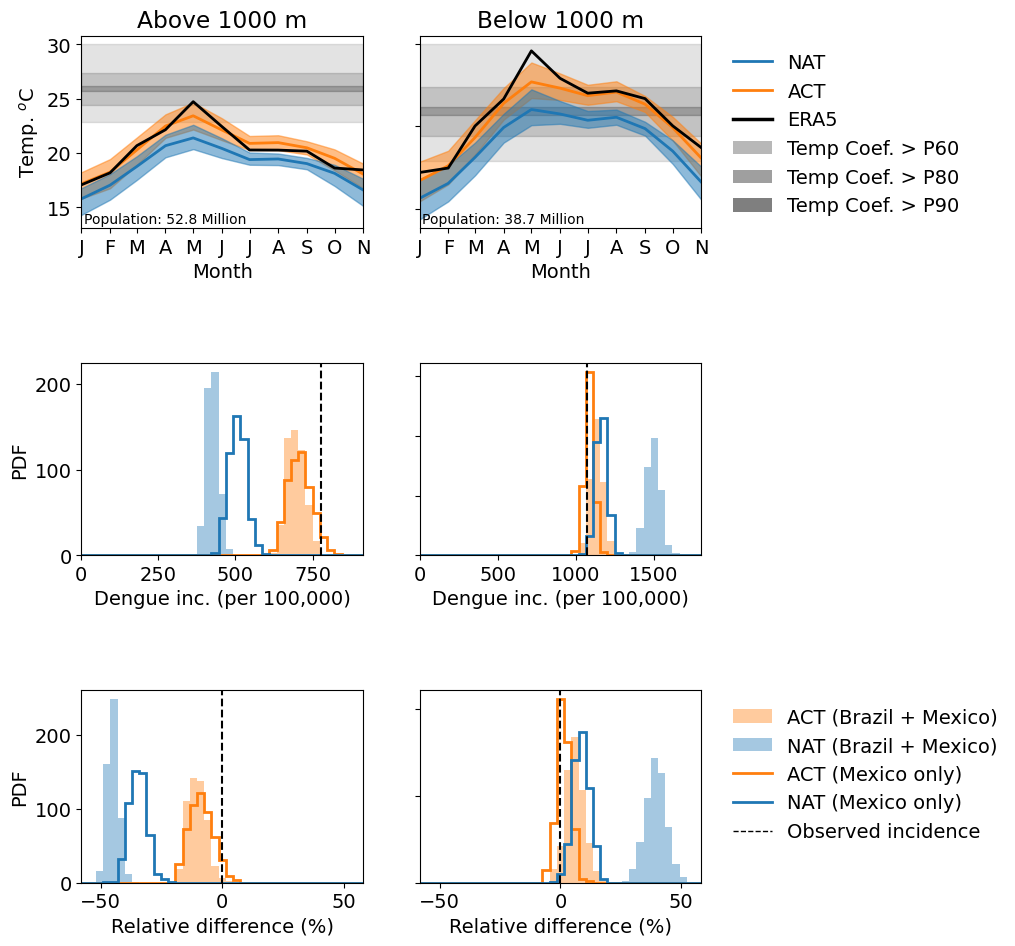

In [31]:
# ---- Combined figure: both models' dengue incidence in the same panels ----
# Model 1 (Brazil + Mexico) is drawn as filled histograms, Model 2 (Mexico
# only) as outlined step histograms -- same ACT (orange) / NAT (blue) color
# coding as the temperature row, so all four distributions per panel stay
# visually distinguishable.

fig, axarr = plt.subplots(3, len(regions), figsize=(8, 11))
plt.subplots_adjust(wspace=0.2, hspace=0.7)

model_style = {
    1: dict(histtype='bar',  alpha=0.4, linewidth=0),
    2: dict(histtype='step', alpha=1.0, linewidth=2),
}

# ---- Row 0: temperature (shared across both models) ----
spans = [
    [0.6, 22.9, 30, '#737373'],
    [0.8, 24.4, 27.4, '#404040'],
    [0.9, 25.7, 26.2, '#000000'],
]

for i, region in enumerate(regions):
    ax = axarr[0, i]

    ext_subset = ext_temp[ext_temp['region'] == region]
    nat_subset = nat_temp[nat_temp['region'] == region]

    for span in spans:
        ax.axhspan(span[1], span[2], color=span[3], alpha=0.2)

    ax.fill_between(
        ext_subset[ext_subset['quantile'] == 0.5]['date_first_symptoms'],
        ext_subset[ext_subset['quantile'] == 0.025]['tas'],
        ext_subset[ext_subset['quantile'] == 0.975]['tas'],
        color='C1', alpha=0.5,
    )
    ax.plot(
        ext_subset[ext_subset['quantile'] == 0.5]['date_first_symptoms'],
        ext_subset[ext_subset['quantile'] == 0.5]['tas'],
        color='C1', lw=2,
    )

    ax.fill_between(
        nat_subset[nat_subset['quantile'] == 0.5]['date_first_symptoms'],
        nat_subset[nat_subset['quantile'] == 0.025]['tas'],
        nat_subset[nat_subset['quantile'] == 0.975]['tas'],
        color='C0', alpha=0.5,
    )
    ax.plot(
        nat_subset[nat_subset['quantile'] == 0.5]['date_first_symptoms'],
        nat_subset[nat_subset['quantile'] == 0.5]['tas'],
        color='C0', lw=2,
    )

    ax.plot(
        obs[obs['region'] == region]['date_first_symptoms'],
        obs[obs['region'] == region]['mean_2m_air_temp_degree1'],
        color='k', lw=2,
    )

    ax.set_title(region)
    ax.set_xlim(pd.to_datetime(WINDOW_START), pd.to_datetime(WINDOW_END))
    ax.set_xticks(pd.date_range(WINDOW_START, WINDOW_END, freq='MS'))
    ax.set_xticklabels(list('JFMAMJJASON'))
    ax.set_xlabel('Month')
    ax.text(0.01, 0.01, f"Population: {pop.loc[region, 'population']:.1f} Million",
            transform=ax.transAxes, fontsize=10, verticalalignment='bottom')

# ---- Row 1: absolute incidence, both models overlaid ----
for i, region in enumerate(regions):
    ax = axarr[1, i]

    vmax = max(
        annual[m][scenario][annual[m][scenario]['region'] == region]['predicted_incidence'].max()
        for m in model_labels for scenario in ('act', 'nat')
    ) * 1.1
    bins = np.linspace(0, vmax, 40)

    for model_idx, style in model_style.items():
        ext_r = annual[model_idx]['act']
        nat_r = annual[model_idx]['nat']
        ax.hist(ext_r[ext_r['region'] == region]['predicted_incidence'], color='C1', bins=bins, **style)
        ax.hist(nat_r[nat_r['region'] == region]['predicted_incidence'], color='C0', bins=bins, **style)

    # Both models' observed baselines should coincide (same real event) --
    # draw model 1's for reference.
    ax.axvline(annual[1]['act_region'][region], color='k', ls='--')

    ax.set_xlim([0, vmax])
    ax.set_xlabel('Dengue inc. (per 100,000)')

# ---- Row 2: relative incidence, both models overlaid ----
for i, region in enumerate(regions):
    ax = axarr[2, i]
    baseline = annual[1]['act_region'][region]

    all_rel = []
    for model_idx in model_labels:
        for scenario in ('act', 'nat'):
            df_s = annual[model_idx][scenario]
            all_rel.append(100 * (df_s[df_s['region'] == region]['predicted_incidence'] - baseline) / baseline)
    vlim = max(r.abs().max() for r in all_rel) * 1.1
    bins = np.linspace(-vlim, vlim, 40)

    for model_idx, style in model_style.items():
        ext_r = annual[model_idx]['act']
        nat_r = annual[model_idx]['nat']
        ext_rel = 100 * (ext_r[ext_r['region'] == region]['predicted_incidence'] - baseline) / baseline
        nat_rel = 100 * (nat_r[nat_r['region'] == region]['predicted_incidence'] - baseline) / baseline
        ax.hist(ext_rel, color='C1', bins=bins, **style)
        ax.hist(nat_rel, color='C0', bins=bins, **style)

    ax.axvline(0, color='k', ls='--')
    ax.set_xlim([-vlim, vlim])
    ax.set_xlabel('Relative difference (%)')

axarr[0, 0].set_ylabel(r'Temp. $^o$C')
axarr[1, 0].set_ylabel('PDF')
axarr[2, 0].set_ylabel('PDF')

for i in range(1, len(regions)):
    axarr[0, i].set_yticklabels([])
    axarr[1, i].set_yticklabels([])
    axarr[2, i].set_yticklabels([])

legend_elements1 = [
    Line2D([0], [0], color='C0', lw=2, label='NAT'),
    Line2D([0], [0], color='C1', lw=2, label='ACT'),
    Line2D([0], [0], color='k', lw=2.5, label='ERA5'),
    Patch(facecolor='#737373', alpha=0.5, label='Temp Coef. > P60'),
    Patch(facecolor='#404040', alpha=0.5, label='Temp Coef. > P80'),
    Patch(facecolor='#000000', alpha=0.5, label='Temp Coef. > P90'),
]
legend_elements2 = [
    Patch(facecolor='C1', alpha=0.4, label='ACT (Brazil + Mexico)'),
    Patch(facecolor='C0', alpha=0.4, label='NAT (Brazil + Mexico)'),
    Line2D([0], [0], color='C1', lw=2, label='ACT (Mexico only)'),
    Line2D([0], [0], color='C0', lw=2, label='NAT (Mexico only)'),
    Line2D([0], [0], color='k', ls='--', lw=1, label='Observed incidence'),
]

axarr[0, -1].legend(handles=legend_elements1, frameon=False, ncol=1, bbox_to_anchor=(1.05, 1))
axarr[2, -1].legend(handles=legend_elements2, frameon=False, ncol=1, bbox_to_anchor=(1.05, 1))

plt.savefig('img/figureS18_mexico_temperature_analysis_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [30]:
# ---- ACT vs NAT percentage difference (printed, not plotted) ----
# Percentage change of ACT relative to the NAT (counterfactual) mean:
#   100 * (mean(ACT) - mean(NAT)) / mean(NAT)
# per model and region.

diff_rows = []
for model_idx, label in model_labels.items():
    for region in regions:
        act_vals = annual[model_idx]['act']
        nat_vals = annual[model_idx]['nat']
        act_mean = act_vals[act_vals['region'] == region]['predicted_incidence'].mean()
        nat_mean = nat_vals[nat_vals['region'] == region]['predicted_incidence'].mean()
        pct_diff = 100 * (act_mean - nat_mean) / nat_mean

        diff_rows.append({
            'model': label,
            'region': region,
            'act_avg': act_mean,
            'nat_avg': nat_mean,
            'pct_diff_act_vs_nat': pct_diff,
        })

diff_table = pd.DataFrame(diff_rows)
diff_table


,model,region,act_avg,nat_avg,pct_diff_act_vs_nat
0,Brazil + Mexico,Above 1000 m,695.311480,425.577160,63.380826
1,Brazil + Mexico,Below 1000 m,1135.301906,1494.990432,-24.059587
2,Mexico only,Above 1000 m,708.438759,505.728297,40.082879
3,Mexico only,Below 1000 m,1084.532735,1164.627540,-6.877289
